# Credit-Default Modelling — Summary Notebook

**Dataset**: Kaggle *Give Me Some Credit* (2011) · 150,000 borrowers · binary target `SeriousDlqin2yrs`

This notebook consolidates:
1. **EDA** — Data Profiling, Missingness, Distributions, Correlation
2. **Model Comparison** — Logistic Regression · MoE Teacher · KD Student (NN) · CatBoost (Optuna-tuned)


In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import missingno as msno
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, log_loss,
    f1_score, precision_score, recall_score,
    roc_curve, precision_recall_curve, classification_report,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from catboost import CatBoostClassifier, Pool
import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

SEED = 42
GOOD_CLR = '#4C9BE8'
BAD_CLR  = '#E8604C'
np.random.seed(SEED)
torch.manual_seed(SEED)

print("PyTorch :", torch.__version__)
import catboost; print("CatBoost:", catboost.__version__)


PyTorch : 2.8.0
CatBoost: 1.2.10


## 1 · Data Loading & Preprocessing

In [2]:
raw = pd.read_csv('../Data/cs-training.csv', index_col=0)

RENAME = {
    'SeriousDlqin2yrs':                        'defaulted',
    'RevolvingUtilizationOfUnsecuredLines':     'unsecured_credit',
    'age':                                      'age',
    'NumberOfTime30-59DaysPastDueNotWorse':     'delinq_30_59',
    'DebtRatio':                                'debt_ratio',
    'MonthlyIncome':                            'monthly_income',
    'NumberOfOpenCreditLinesAndLoans':          'open_credit',
    'NumberOfTimes90DaysLate':                  'delinq_90',
    'NumberRealEstateLoansOrLines':             'real_estate_loans',
    'NumberOfTime60-89DaysPastDueNotWorse':     'delinq_60_89',
    'NumberOfDependents':                       'dependents',
}
raw = raw.rename(columns=RENAME)

df = raw.copy()
df = df[df['age'] > 0]

# Sentinel treatment: flag codes 96/98, cap delinquency at 10
DELINQ_COLS = ['delinq_30_59', 'delinq_60_89', 'delinq_90']
df['delinq_sentinel'] = (df['delinq_90'] >= 96).astype(int)
for col in DELINQ_COLS:
    df[col] = df[col].clip(upper=10)

# Missing indicators (derived from raw, before imputation)
df['monthly_income_missing'] = raw.loc[df.index, 'monthly_income'].isna().astype(int)
df['dependents_missing']     = raw.loc[df.index, 'dependents'].isna().astype(int)

# Imputation
df['monthly_income'] = df['monthly_income'].fillna(df['monthly_income'].median())
df['dependents']     = df['dependents'].fillna(0)

FEATURE_COLS = [
    'unsecured_credit', 'age', 'delinq_30_59', 'debt_ratio',
    'monthly_income', 'open_credit', 'delinq_90', 'real_estate_loans',
    'delinq_60_89', 'dependents', 'monthly_income_missing', 'dependents_missing',
    'delinq_sentinel',
]

print(f"Shape          : {df.shape}")
print(f"Default rate   : {df['defaulted'].mean():.3%}")
print(f"Sentinel rows  : {df['delinq_sentinel'].sum():,}")


Shape          : (149999, 14)
Default rate   : 6.684%
Sentinel rows  : 269


## 2 · Exploratory Data Analysis

### 2.1 Data Profiling

In [3]:
# ── Descriptive statistics ────────────────────────────────────────────────────
desc = df[FEATURE_COLS + ['defaulted']].describe().T
desc['missing_%'] = df[FEATURE_COLS + ['defaulted']].isnull().mean().mul(100).round(2)
desc['skewness']  = df[FEATURE_COLS + ['defaulted']].skew().round(3)
print(desc[['count','mean','std','min','25%','50%','75%','max','missing_%','skewness']]
      .to_string(float_format='{:.3f}'.format))


                            count     mean       std    min      25%      50%      75%         max  missing_%  skewness
unsecured_credit       149999.000    6.048   249.756  0.000    0.030    0.154    0.559   50708.000      0.000    97.631
age                    149999.000   52.296    14.771 21.000   41.000   52.000   63.000     109.000      0.000     0.189
delinq_30_59           149999.000    0.263     0.809  0.000    0.000    0.000    0.000      10.000      0.000     5.754
debt_ratio             149999.000  353.007  2037.825  0.000    0.175    0.367    0.868  329664.000      0.000    95.158
monthly_income         149999.000 6418.458 12890.438  0.000 3903.000 5400.000 7400.000 3008750.000      0.000   127.121
open_credit            149999.000    8.453     5.146  0.000    5.000    8.000   11.000      58.000      0.000     1.215
delinq_90              149999.000    0.108     0.635  0.000    0.000    0.000    0.000      10.000      0.000    10.360
real_estate_loans      149999.000    1.0

### 2.2 Missingness Analysis

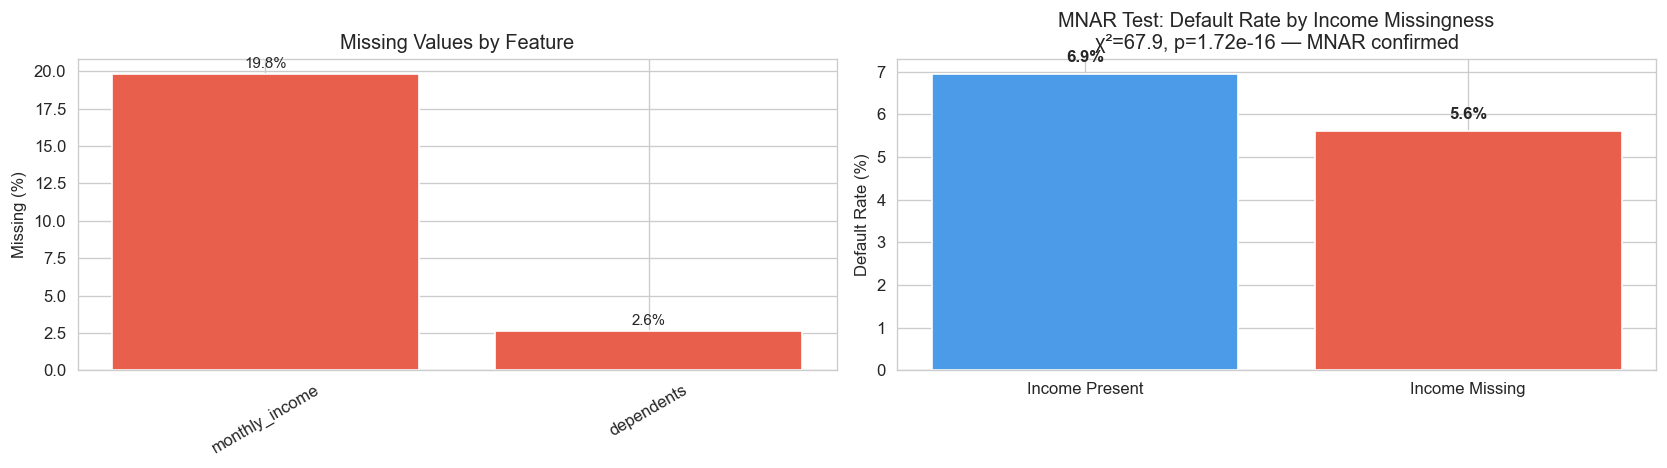

monthly_income : 19.8% missing  —  MNAR (p=1.72e-16)
dependents     : 2.6% missing  —  imputed with 0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart of completeness
miss_pct = raw.rename(columns=RENAME).isnull().mean().mul(100).sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]
axes[0].bar(miss_pct.index, miss_pct.values, color=BAD_CLR, edgecolor='white')
axes[0].set_ylabel('Missing (%)')
axes[0].set_title('Missing Values by Feature')
axes[0].tick_params(axis='x', rotation=30)
for bar, v in zip(axes[0].patches, miss_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

# MNAR test for monthly_income
df_mnar = df.copy()
df_mnar['income_missing'] = df_mnar['monthly_income_missing']
ct = pd.crosstab(df_mnar['income_missing'], df_mnar['defaulted'])
chi2, p_val, _, _ = stats.chi2_contingency(ct)
default_rate_present = df_mnar[df_mnar['income_missing']==0]['defaulted'].mean()
default_rate_missing = df_mnar[df_mnar['income_missing']==1]['defaulted'].mean()

axes[1].bar(['Income Present', 'Income Missing'],
            [default_rate_present * 100, default_rate_missing * 100],
            color=[GOOD_CLR, BAD_CLR], edgecolor='white')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_title(f'MNAR Test: Default Rate by Income Missingness\n'
                  f'χ²={chi2:.1f}, p={p_val:.2e} — {"MNAR confirmed" if p_val < 0.05 else "no evidence"}')
for bar, v in zip(axes[1].patches, [default_rate_present*100, default_rate_missing*100]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"monthly_income : {miss_pct.get('monthly_income', 0):.1f}% missing  —  MNAR (p={p_val:.2e})")
print(f"dependents     : {miss_pct.get('dependents', 0):.1f}% missing  —  imputed with 0")


### 2.3 Feature Distributions

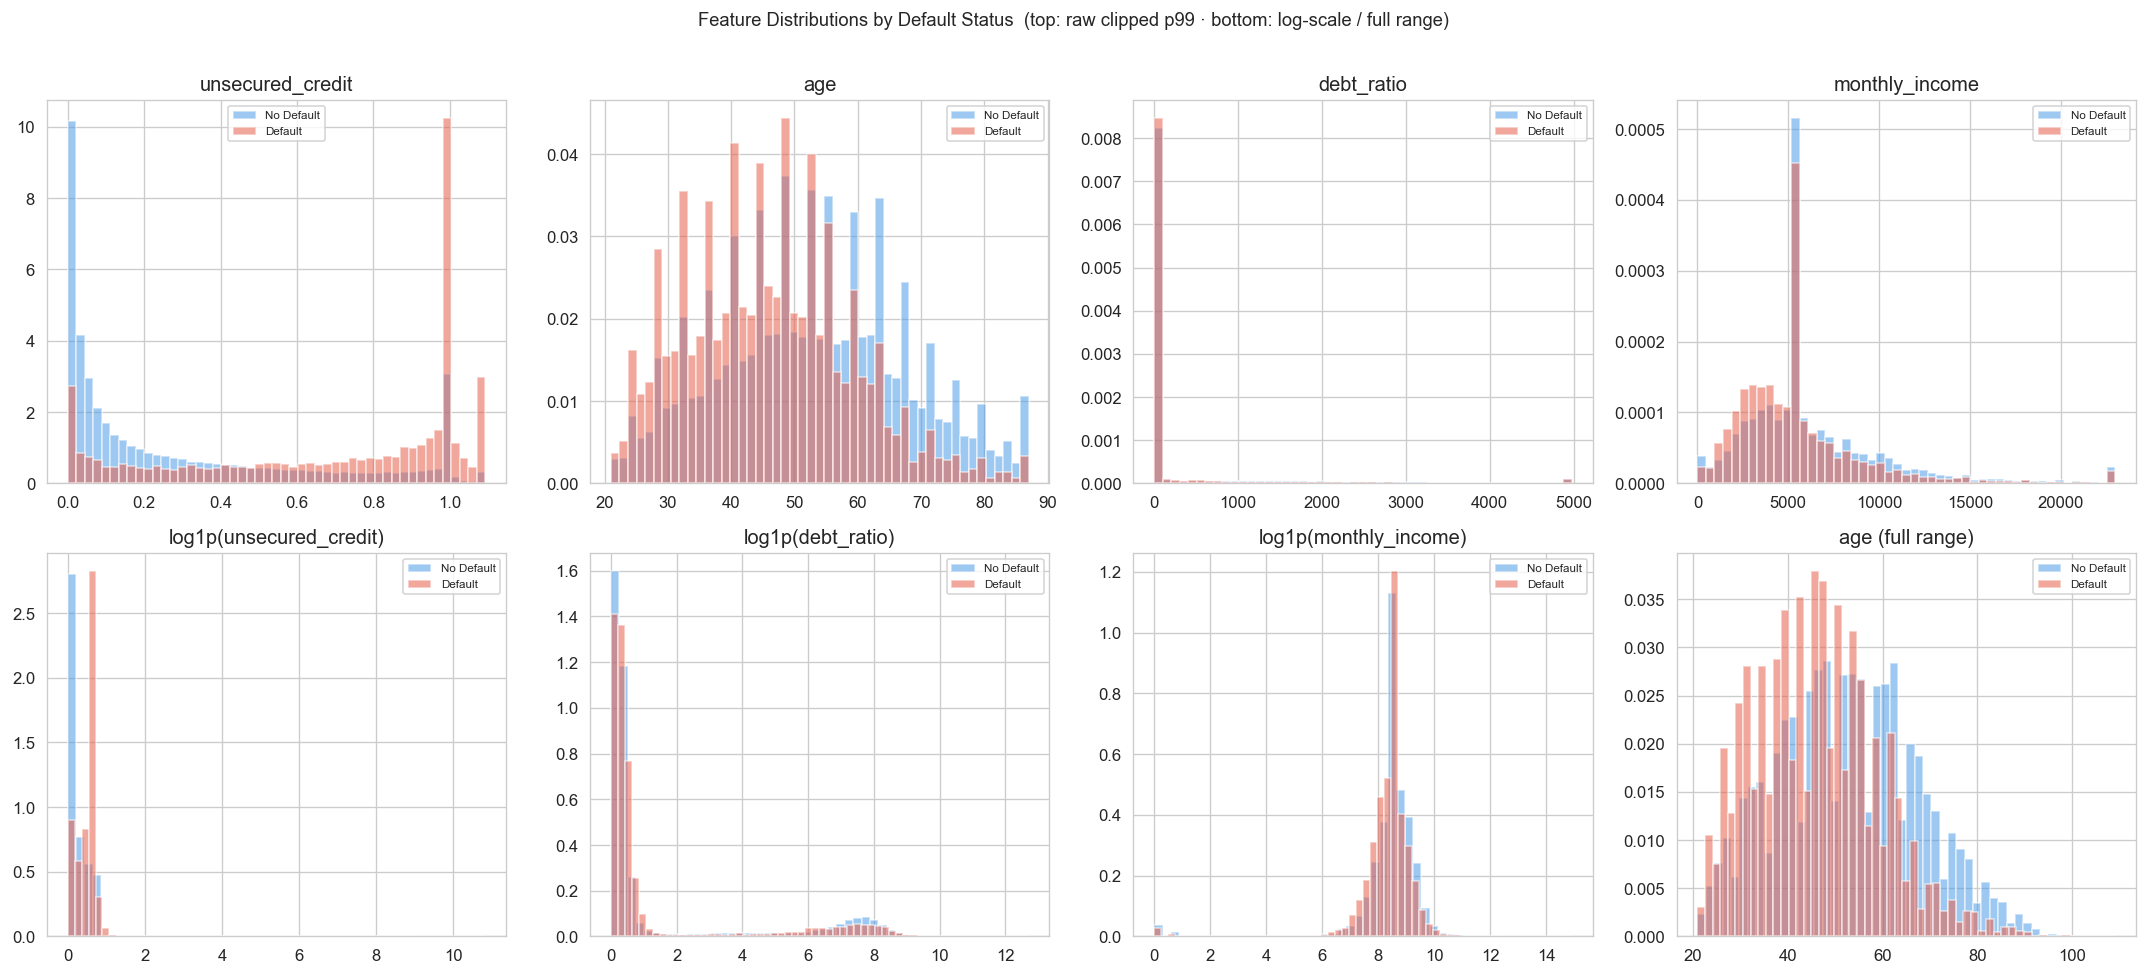

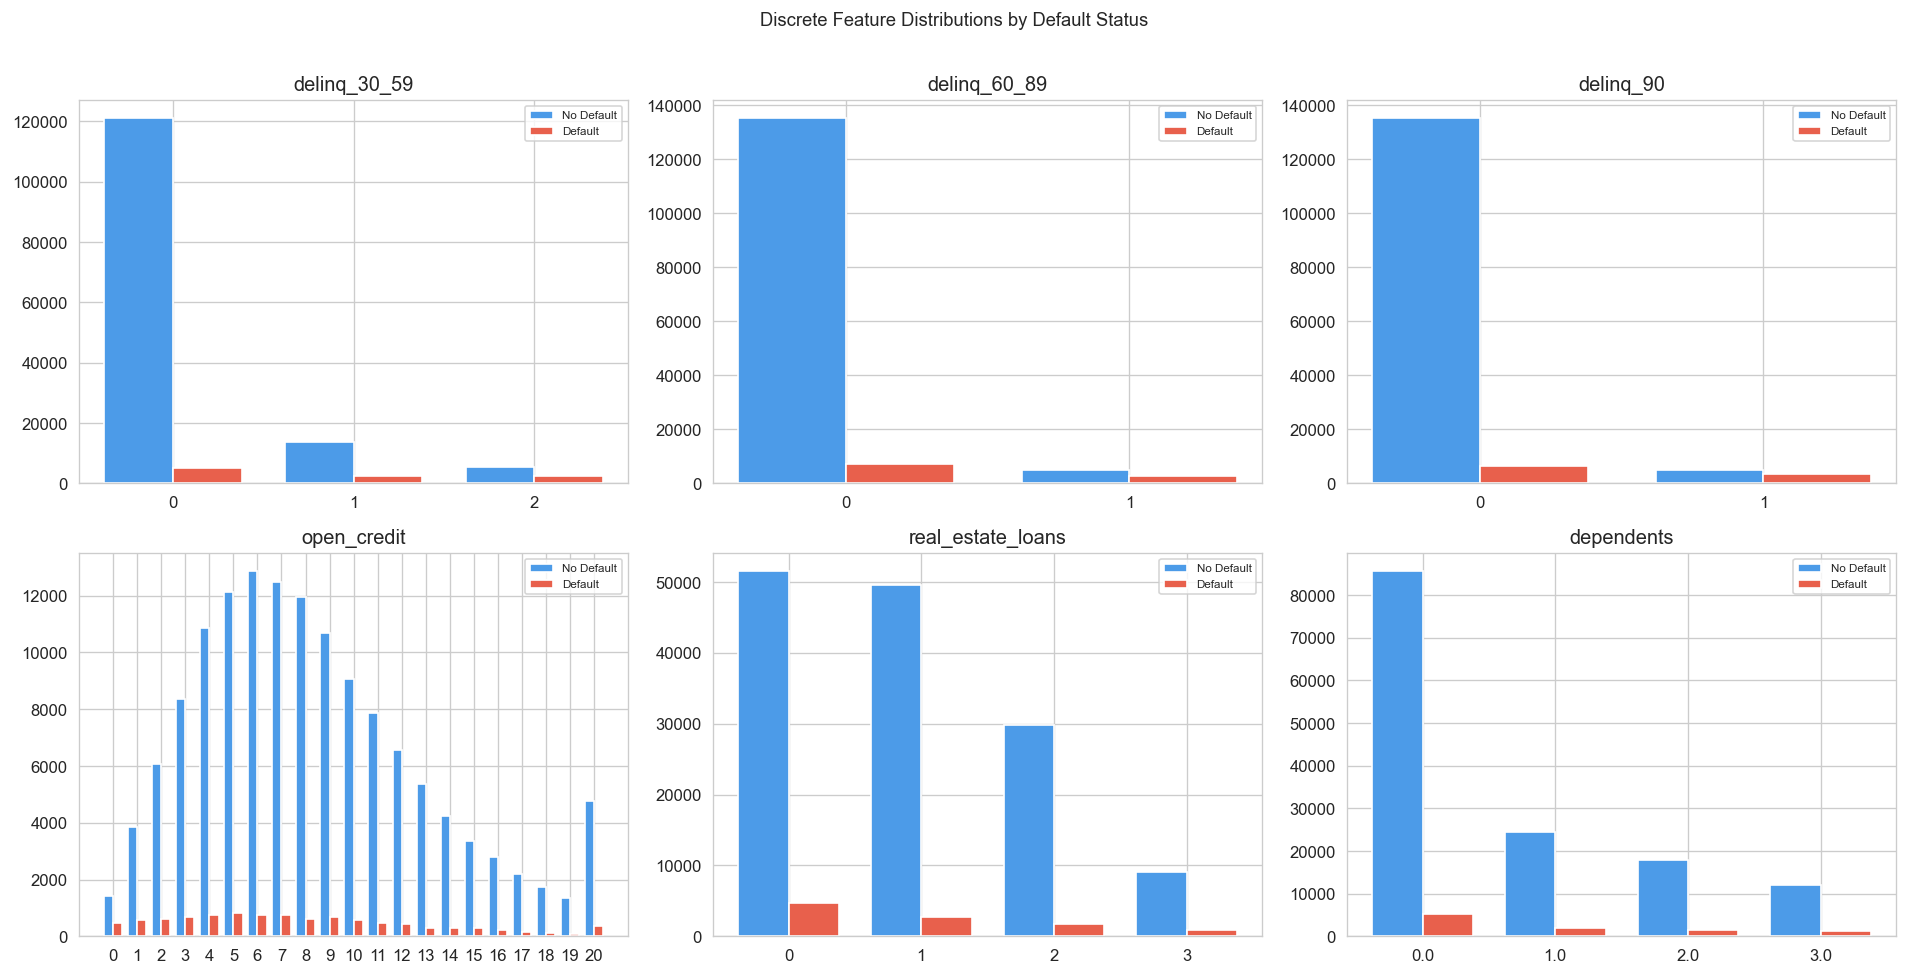

In [5]:
CONT_FEATS = ['unsecured_credit', 'age', 'debt_ratio', 'monthly_income']
DISC_FEATS = ['delinq_30_59', 'delinq_60_89', 'delinq_90', 'open_credit',
              'real_estate_loans', 'dependents']

df0 = df[df['defaulted'] == 0]
df1 = df[df['defaulted'] == 1]

# Continuous features
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, feat in zip(axes[0], CONT_FEATS):
    clip_val = min(df[feat].quantile(0.99), df[feat].median() + 5 * df[feat].std())
    bins = np.linspace(df[feat].min(), clip_val, 50)
    ax.hist(df0[feat].clip(upper=clip_val), bins=bins, color=GOOD_CLR,
            alpha=0.55, density=True, label='No Default')
    ax.hist(df1[feat].clip(upper=clip_val), bins=bins, color=BAD_CLR,
            alpha=0.55, density=True, label='Default')
    ax.set_title(feat)
    ax.legend(fontsize=7)

# log1p view for skewed features
LOG_FEATS = ['unsecured_credit', 'debt_ratio', 'monthly_income',
             'unsecured_credit']   # reuse slot for age distribution
log_labels = ['log1p(unsecured_credit)', 'log1p(debt_ratio)',
              'log1p(monthly_income)', 'age (full range)']
extra_feats = ['unsecured_credit', 'debt_ratio', 'monthly_income', 'age']
for ax, feat, lbl in zip(axes[1], extra_feats, log_labels):
    if 'log1p' in lbl:
        vals0 = np.log1p(df0[feat])
        vals1 = np.log1p(df1[feat])
    else:
        vals0, vals1 = df0[feat], df1[feat]
    ax.hist(vals0, bins=50, color=GOOD_CLR, alpha=0.55, density=True, label='No Default')
    ax.hist(vals1, bins=50, color=BAD_CLR,  alpha=0.55, density=True, label='Default')
    ax.set_title(lbl)
    ax.legend(fontsize=7)

fig.suptitle('Feature Distributions by Default Status  (top: raw clipped p99 · bottom: log-scale / full range)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

# Discrete features — bar charts
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, feat in zip(axes.flat, DISC_FEATS):
    cap = int(df[feat].quantile(0.97))
    vals = df[feat].clip(upper=cap)
    counts0 = vals[df['defaulted']==0].value_counts().sort_index()
    counts1 = vals[df['defaulted']==1].value_counts().sort_index()
    idx = sorted(set(counts0.index) | set(counts1.index))
    w = 0.38
    x = np.arange(len(idx))
    ax.bar(x - w/2, [counts0.get(i,0) for i in idx], width=w,
           color=GOOD_CLR, label='No Default')
    ax.bar(x + w/2, [counts1.get(i,0) for i in idx], width=w,
           color=BAD_CLR,  label='Default')
    ax.set_xticks(x); ax.set_xticklabels(idx)
    ax.set_title(feat); ax.legend(fontsize=7)

plt.suptitle('Discrete Feature Distributions by Default Status', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()


### 2.4 Correlation Analysis

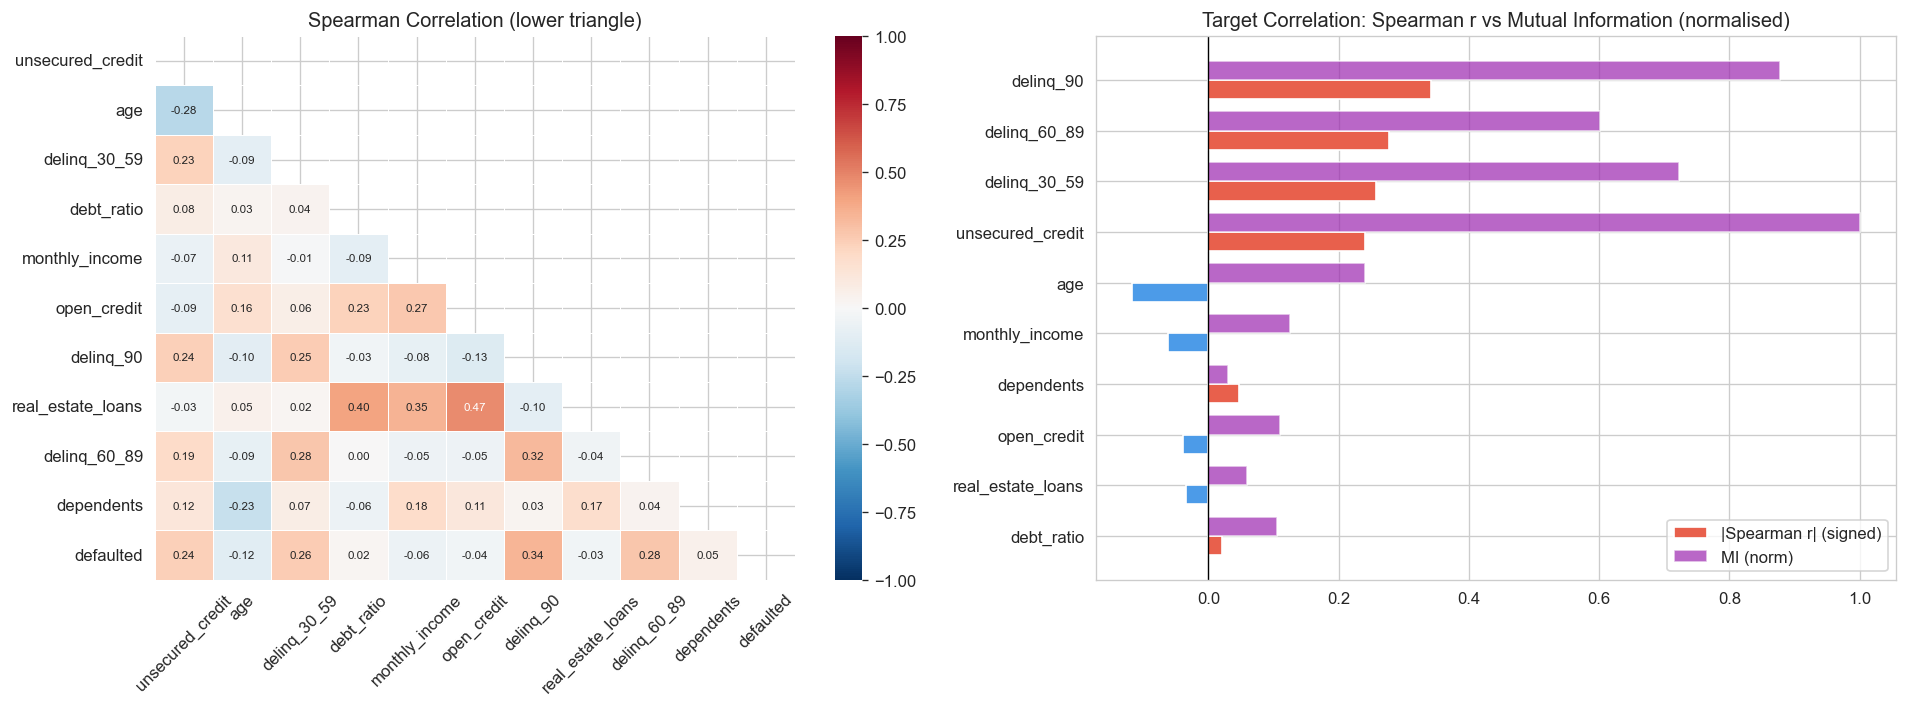

Top predictors by Spearman |r|:
delinq_90            0.342349
delinq_60_89         0.277111
delinq_30_59         0.257419
unsecured_credit     0.240382
age                  0.117038
monthly_income       0.061696
dependents           0.046908
open_credit          0.038588
real_estate_loans    0.034117
debt_ratio           0.020597


In [6]:
from sklearn.feature_selection import mutual_info_classif

feat_cols_eda = ['unsecured_credit', 'age', 'delinq_30_59', 'debt_ratio',
                 'monthly_income', 'open_credit', 'delinq_90', 'real_estate_loans',
                 'delinq_60_89', 'dependents']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Spearman heatmap (lower triangle)
corr_sp = df[feat_cols_eda + ['defaulted']].corr(method='spearman', numeric_only=True)
mask    = np.triu(np.ones_like(corr_sp, dtype=bool))
sns.heatmap(corr_sp, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5, ax=axes[0],
            annot_kws={'size': 7})
axes[0].set_title('Spearman Correlation (lower triangle)')
axes[0].tick_params(axis='x', rotation=45)

# Target correlation bar chart vs MI
target_corr = corr_sp['defaulted'].drop('defaulted').sort_values(key=abs)
discrete_mask = [c in ['delinq_30_59','delinq_60_89','delinq_90','open_credit',
                        'real_estate_loans','dependents'] for c in feat_cols_eda]
mi_scores = mutual_info_classif(
    df[feat_cols_eda].values, df['defaulted'].values,
    discrete_features=discrete_mask, random_state=SEED)
mi_series = pd.Series(mi_scores, index=feat_cols_eda).reindex(target_corr.index)
mi_norm   = mi_series / mi_series.max()

x = np.arange(len(target_corr))
w = 0.38
colors_bar = [BAD_CLR if v > 0 else GOOD_CLR for v in target_corr.values]
axes[1].barh(x - w/2, target_corr.values, height=w, color=colors_bar, label='|Spearman r| (signed)')
axes[1].barh(x + w/2, mi_norm.values,     height=w, color='#9C27B0', alpha=0.7, label='MI (norm)')
axes[1].set_yticks(x); axes[1].set_yticklabels(target_corr.index)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Target Correlation: Spearman r vs Mutual Information (normalised)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Top predictors by Spearman |r|:")
print(target_corr.abs().sort_values(ascending=False).to_string())


## 3 · Train / Val / Test Split

In [7]:
X_all = df[FEATURE_COLS].values.astype(np.float32)
y_all = df['defaulted'].values.astype(np.float32)

X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_all, test_size=0.15, random_state=SEED, stratify=y_all)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, random_state=SEED, stratify=y_temp)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

n_pos = int(y_train.sum())
n_neg = int(len(y_train) - n_pos)
class_ratio = n_neg / n_pos

print(f"Train : {X_train_s.shape}  default={y_train.mean():.3%}")
print(f"Val   : {X_val_s.shape}   default={y_val.mean():.3%}")
print(f"Test  : {X_test_s.shape}  default={y_test.mean():.3%}")
print(f"class_ratio (n_neg/n_pos) : {class_ratio:.2f}")

# Threshold helpers — used by all models
PREC_TARGET = 0.50

def get_thresholds(y_v, val_probs):
    thr = np.linspace(0.01, 0.99, 499)
    pv  = np.array([precision_score(y_v, val_probs >= t, zero_division=0) for t in thr])
    rv  = np.array([recall_score(y_v,    val_probs >= t, zero_division=0) for t in thr])
    fv  = np.array([f1_score(y_v,        val_probs >= t, zero_division=0) for t in thr])
    thresh_f1   = thr[np.argmax(fv)]
    feasible    = pv >= PREC_TARGET
    thresh_prec = thr[feasible.nonzero()[0][np.argmax(rv[feasible])]] if feasible.any() else thr[np.argmax(pv)]
    return thresh_f1, thresh_prec

def model_metrics(name, y_true, probs, thresh_f1, thresh_prec):
    pf1   = (probs >= thresh_f1).astype(int)
    pprec = (probs >= thresh_prec).astype(int)
    return {
        'Model':          name,
        'ROC-AUC':        round(roc_auc_score(y_true, probs), 4),
        'Avg Precision':  round(average_precision_score(y_true, probs), 4),
        # Max-F1 threshold
        'Prec (F1-t)':    round(precision_score(y_true, pf1, zero_division=0), 4),
        'Rec  (F1-t)':    round(recall_score(y_true, pf1, zero_division=0), 4),
        'F1   (F1-t)':    round(f1_score(y_true, pf1, zero_division=0), 4),
        # Precision-targeted threshold
        f'Prec (P50-t)':  round(precision_score(y_true, pprec, zero_division=0), 4),
        f'Rec  (P50-t)':  round(recall_score(y_true, pprec, zero_division=0), 4),
        f'F1   (P50-t)':  round(f1_score(y_true, pprec, zero_division=0), 4),
        '_probs':         probs,
        '_tf1':           thresh_f1,
        '_tprec':         thresh_prec,
    }

results = []   # collect one dict per model


Train : (104999, 13)  default=6.684%
Val   : (22500, 13)   default=6.684%
Test  : (22500, 13)  default=6.684%
class_ratio (n_neg/n_pos) : 13.96


## 4 · Models

### 4.1 Logistic Regression (Baseline)

Linear baseline with L2 regularisation. `monthly_income` log1p-transformed before scaling
(reduces right skew; helps the linear decision boundary).


In [8]:
# Feature matrix: all 13 features, log1p on monthly_income copy
LR_FEAT_IDX = list(range(len(FEATURE_COLS)))  # all 13
monthly_idx  = FEATURE_COLS.index('monthly_income')

X_train_lr = X_train_s.copy()
X_val_lr   = X_val_s.copy()
X_test_lr  = X_test_s.copy()
# monthly_income is already standardised; apply log1p on the raw column separately
df_lr = df[FEATURE_COLS].copy()
df_lr['monthly_income'] = np.log1p(df_lr['monthly_income'])

scaler_lr  = StandardScaler()
X_all_lr   = df_lr.values.astype(np.float32)
X_t_lr, X_te_lr, y_t_lr, y_te_lr = train_test_split(
    X_all_lr, y_all, test_size=0.15, random_state=SEED, stratify=y_all)
X_tr_lr, X_v_lr, y_tr_lr, y_v_lr = train_test_split(
    X_t_lr, y_t_lr, test_size=0.15/0.85, random_state=SEED, stratify=y_t_lr)

X_tr_lr_s = scaler_lr.fit_transform(X_tr_lr)
X_v_lr_s  = scaler_lr.transform(X_v_lr)
X_te_lr_s = scaler_lr.transform(X_te_lr)

lr = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=SEED)
lr.fit(X_tr_lr_s, y_tr_lr)

lr_val_probs  = lr.predict_proba(X_v_lr_s)[:, 1]
lr_test_probs = lr.predict_proba(X_te_lr_s)[:, 1]

lr_tf1, lr_tprec = get_thresholds(y_v_lr, lr_val_probs)
results.append(model_metrics('Logistic Regression', y_te_lr, lr_test_probs, lr_tf1, lr_tprec))

print(f"LR  ROC-AUC : {roc_auc_score(y_te_lr, lr_test_probs):.4f}")
print(f"    Avg Prec: {average_precision_score(y_te_lr, lr_test_probs):.4f}")
print(f"    thresh_f1={lr_tf1:.3f}  thresh_prec={lr_tprec:.3f}")
print()
print(classification_report(y_te_lr,
      (lr_test_probs >= lr_tprec).astype(int),
      target_names=['No Default','Default']))


LR  ROC-AUC : 0.8245
    Avg Prec: 0.3543
    thresh_f1=0.677  thresh_prec=0.929

              precision    recall  f1-score   support

  No Default       0.95      0.98      0.97     20996
     Default       0.52      0.24      0.33      1504

    accuracy                           0.93     22500
   macro avg       0.73      0.61      0.65     22500
weighted avg       0.92      0.93      0.92     22500



### 4.2 Mixture-of-Experts (MoE) Teacher

Soft-MoE with K=3 experts, Switch Transformer auxiliary load-balancing loss, and
`pos_weight=7` for class imbalance. `monthly_income` is log1p-transformed in the
feature matrix (reduces gradient leverage from outliers).


In [9]:
# ── MoE feature matrix: same split but log1p on monthly_income ────────────────
df_moe = df[FEATURE_COLS].copy()
df_moe['monthly_income'] = np.log1p(df_moe['monthly_income'])

X_all_moe  = df_moe.values.astype(np.float32)
X_t_m, X_te_m, y_t_m, y_te_m = train_test_split(
    X_all_moe, y_all, test_size=0.15, random_state=SEED, stratify=y_all)
X_tr_m, X_v_m, y_tr_m, y_v_m = train_test_split(
    X_t_m, y_t_m, test_size=0.15/0.85, random_state=SEED, stratify=y_t_m)

scaler_moe = StandardScaler()
X_tr_m_s   = scaler_moe.fit_transform(X_tr_m)
X_v_m_s    = scaler_moe.transform(X_v_m)
X_te_m_s   = scaler_moe.transform(X_te_m)


In [10]:
# ── Model definition ──────────────────────────────────────────────────────────
class Expert(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.BatchNorm1d(hidden_dim),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.BatchNorm1d(hidden_dim),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )
    def forward(self, x): return self.net(x)

class GatingNetwork(nn.Module):
    def __init__(self, input_dim, n_experts=3):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(), nn.Linear(32, n_experts))
    def forward(self, x):
        return F.softmax(self.gate(x), dim=-1)

class MixtureOfExperts(nn.Module):
    def __init__(self, input_dim, n_experts=3, hidden_dim=64, dropout=0.3):
        super().__init__()
        self.experts = nn.ModuleList(
            [Expert(input_dim, hidden_dim, dropout) for _ in range(n_experts)])
        self.gate = GatingNetwork(input_dim, n_experts)
    def forward(self, x):
        gw  = self.gate(x)
        out = torch.cat([e(x) for e in self.experts], dim=1)
        return (gw * out).sum(dim=1), gw

def auxiliary_loss(gate_weights, alpha=0.01):
    K    = gate_weights.shape[1]
    topk = gate_weights.argmax(dim=1)
    f_k  = torch.stack([(topk == k).float().mean() for k in range(K)])
    P_k  = gate_weights.mean(dim=0)
    return alpha * K * (f_k * P_k).sum()


In [11]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
HIDDEN_DIM   = 64
DROPOUT      = 0.3
N_EXPERTS    = 3
BATCH_SIZE   = 512
LR_MOE       = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS   = 400   # reduced from 400 for summary speed; increase for full run
PATIENCE     = 100
AUX_ALPHA    = 0.01
POS_WEIGHT   = 7.0

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

def make_loader(X, y, bs, shuffle=True):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.float32))
    return DataLoader(ds, batch_size=bs, shuffle=shuffle)

train_loader = make_loader(X_tr_m_s, y_tr_m, BATCH_SIZE, True)
val_loader   = make_loader(X_v_m_s,  y_v_m,  BATCH_SIZE, False)
test_loader  = make_loader(X_te_m_s, y_te_m, BATCH_SIZE, False)


Device : cpu


In [12]:
# ── Training loop ─────────────────────────────────────────────────────────────
torch.manual_seed(SEED)
model = MixtureOfExperts(len(FEATURE_COLS), N_EXPERTS, HIDDEN_DIM, DROPOUT).to(device)

pos_wt    = torch.tensor([POS_WEIGHT], dtype=torch.float32).to(device)
bce_fn    = nn.BCEWithLogitsLoss(pos_weight=pos_wt)
optimizer = torch.optim.Adam(model.parameters(), lr=LR_MOE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3)

history = {'train_loss': [], 'val_loss': [], 'val_auc': []}
best_auc, patience_ctr, best_state = 0.0, 0, None

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    ep_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        logits, gw = model(Xb)
        loss = bce_fn(logits, yb) + auxiliary_loss(gw, AUX_ALPHA)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        ep_loss += loss.item() * len(yb)
    ep_loss /= len(y_tr_m)

    model.eval()
    v_loss, v_probs = 0.0, []
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            lg, gw = model(Xb)
            v_loss += (bce_fn(lg, yb) + auxiliary_loss(gw, AUX_ALPHA)).item() * len(yb)
            v_probs.append(torch.sigmoid(lg).cpu().numpy())
    v_loss /= len(y_v_m)
    v_probs = np.concatenate(v_probs)
    val_auc = roc_auc_score(y_v_m, v_probs)
    scheduler.step(val_auc)

    history['train_loss'].append(ep_loss)
    history['val_loss'].append(v_loss)
    history['val_auc'].append(val_auc)

    if val_auc > best_auc:
        best_auc, patience_ctr = val_auc, 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"Early stop at epoch {epoch}  best_val_auc={best_auc:.4f}")
            break

model.load_state_dict(best_state)
print(f"Training complete.  Best val AUC = {best_auc:.4f}")


Early stop at epoch 145  best_val_auc=0.8299
Training complete.  Best val AUC = 0.8299


In [13]:
# ── Test-set inference ────────────────────────────────────────────────────────
model.eval()
moe_probs_list, gate_list = [], []
with torch.no_grad():
    for Xb, _ in test_loader:
        lg, gw = model(Xb.to(device))
        moe_probs_list.append(torch.sigmoid(lg).cpu().numpy())
        gate_list.append(gw.cpu().numpy())

moe_test_probs = np.concatenate(moe_probs_list)
test_gate_w    = np.concatenate(gate_list)

moe_tf1, moe_tprec = get_thresholds(y_v_m, v_probs)
results.append(model_metrics('MoE Teacher', y_te_m, moe_test_probs, moe_tf1, moe_tprec))

print(f"MoE ROC-AUC : {roc_auc_score(y_te_m, moe_test_probs):.4f}")
print(f"    Avg Prec: {average_precision_score(y_te_m, moe_test_probs):.4f}")
print(f"    thresh_f1={moe_tf1:.3f}  thresh_prec={moe_tprec:.3f}")
print()
print(classification_report(y_te_m,
      (moe_test_probs >= moe_tprec).astype(int),
      target_names=['No Default','Default']))


MoE ROC-AUC : 0.8430
    Avg Prec: 0.3613
    thresh_f1=0.630  thresh_prec=0.833

              precision    recall  f1-score   support

  No Default       0.95      0.99      0.97     20996
     Default       0.53      0.21      0.30      1504

    accuracy                           0.93     22500
   macro avg       0.74      0.60      0.63     22500
weighted avg       0.92      0.93      0.92     22500



### 4.3 Knowledge-Distillation Student (2-layer NN)

A lightweight 2-layer MLP trained to mimic the MoE teacher's soft probability
output (temperature-scaled at T=3). The soft labels carry richer signal than
the binary target alone.


In [14]:
TEMPERATURE = 3.0

# ── Soft labels from teacher ──────────────────────────────────────────────────
# IMPORTANT: iterate raw numpy arrays in order, NOT the shuffled train_loader.
# Using train_loader (shuffle=True) would concatenate batches in shuffled order,
# misaligning soft labels with the X rows passed to train_student — causing the
# student to learn from completely wrong targets.
model.eval()
def get_soft_labels(X_np, batch=1024):
    soft = []
    with torch.no_grad():
        for i in range(0, len(X_np), batch):
            Xb = torch.tensor(X_np[i:i+batch], dtype=torch.float32).to(device)
            logits, _ = model(Xb)
            soft.append(torch.sigmoid(logits / TEMPERATURE).cpu().numpy())
    return np.concatenate(soft)

train_soft = get_soft_labels(X_tr_m_s)
val_soft   = get_soft_labels(X_v_m_s)

print(f"Soft-label stats (train): min={train_soft.min():.4f}  "
      f"max={train_soft.max():.4f}  mean={train_soft.mean():.4f}")
print(f"Soft-label mean for positives : {train_soft[y_tr_m==1].mean():.4f}")
print(f"Soft-label mean for negatives : {train_soft[y_tr_m==0].mean():.4f}")

# ── Student architecture ──────────────────────────────────────────────────────
class StudentNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )
    def forward(self, x): return self.net(x).squeeze(1)

def train_student(X_tr, y_soft, X_v, y_v_hard,
                  epochs=100, patience=10, pw=1.0):
    torch.manual_seed(SEED)
    net = StudentNet(X_tr.shape[1]).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=3)
    pos_w = torch.tensor([pw], dtype=torch.float32).to(device)
    kd_fn = nn.BCEWithLogitsLoss()   # soft targets → no pos_weight needed

    ds_tr = TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                          torch.tensor(y_soft, dtype=torch.float32))
    dl_tr = DataLoader(ds_tr, batch_size=512, shuffle=True)
    ds_v  = TensorDataset(torch.tensor(X_v, dtype=torch.float32),
                          torch.tensor(y_v_hard, dtype=torch.float32))
    dl_v  = DataLoader(ds_v, batch_size=512, shuffle=False)

    best_auc, best_state, ctr = 0.0, None, 0
    for ep in range(epochs):
        net.train()
        for Xb, yb in dl_tr:
            Xb, yb = Xb.to(device), yb.to(device)
            loss = kd_fn(net(Xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
        net.eval()
        v_pr = []
        with torch.no_grad():
            for Xb, _ in dl_v:
                v_pr.append(torch.sigmoid(net(Xb.to(device))).cpu().numpy())
        v_pr = np.concatenate(v_pr)
        vauc = roc_auc_score(y_v_hard, v_pr)
        sch.step(vauc)
        if vauc > best_auc:
            best_auc, best_state, ctr = vauc, {k: v.cpu().clone()
                                                for k, v in net.state_dict().items()}, 0
        else:
            ctr += 1
            if ctr >= patience: break
    net.load_state_dict(best_state)
    return net, best_auc

student, student_best_auc = train_student(
    X_tr_m_s, train_soft, X_v_m_s, y_v_m, epochs=150, patience=15)

print(f"Student best val AUC: {student_best_auc:.4f}")


Soft-label stats (train): min=0.0068  max=0.8209  mean=0.3879
Soft-label mean for positives : 0.5263
Soft-label mean for negatives : 0.3780


Student best val AUC: 0.8269


In [15]:
# ── Student test inference ────────────────────────────────────────────────────
student.eval()
stu_probs = []
with torch.no_grad():
    for Xb, _ in test_loader:
        stu_probs.append(torch.sigmoid(student(Xb.to(device))).cpu().numpy())
stu_test_probs = np.concatenate(stu_probs)

# Threshold sweep on val probs (re-run for student)
student.eval()
sv_pr = []
with torch.no_grad():
    for Xb, _ in val_loader:
        sv_pr.append(torch.sigmoid(student(Xb.to(device))).cpu().numpy())
sv_probs = np.concatenate(sv_pr)

stu_tf1, stu_tprec = get_thresholds(y_v_m, sv_probs)
results.append(model_metrics('KD Student (NN)', y_te_m, stu_test_probs, stu_tf1, stu_tprec))

print(f"Student ROC-AUC : {roc_auc_score(y_te_m, stu_test_probs):.4f}")
print(f"        Avg Prec: {average_precision_score(y_te_m, stu_test_probs):.4f}")
print(f"        thresh_f1={stu_tf1:.3f}  thresh_prec={stu_tprec:.3f}")
print()
print(classification_report(y_te_m,
      (stu_test_probs >= stu_tprec).astype(int),
      target_names=['No Default','Default']))


Student ROC-AUC : 0.8412
        Avg Prec: 0.3588
        thresh_f1=0.522  thresh_prec=0.608

              precision    recall  f1-score   support

  No Default       0.95      0.98      0.97     20996
     Default       0.53      0.25      0.33      1504

    accuracy                           0.93     22500
   macro avg       0.74      0.61      0.65     22500
weighted avg       0.92      0.93      0.92     22500



### 4.4 CatBoost + Optuna Hyperparameter Tuning

CatBoost with ordered boosting and symmetric trees, tuned via TPE sampling.
Trees are invariant to monotonic transforms so `monthly_income` is **not** log-transformed.
`N_TRIALS=30` — increase for a more thorough search.


In [16]:
# CatBoost uses the raw (non-log) feature matrix with the standard 70/15/15 split
train_pool = Pool(X_train_s, y_train, feature_names=FEATURE_COLS)
val_pool   = Pool(X_val_s,   y_val,   feature_names=FEATURE_COLS)
test_pool  = Pool(X_test_s,  y_test,  feature_names=FEATURE_COLS)

N_TRIALS = 60   # increase to 50+ for production

def objective(trial):
    params = {
        'learning_rate':       trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth':               trial.suggest_int('depth', 4, 10),
        'iterations':          trial.suggest_int('iterations', 500, 3000),
        'l2_leaf_reg':         trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength':     trial.suggest_float('random_strength', 0.0, 10.0),
        'border_count':        trial.suggest_int('border_count', 32, 255),
        'class_weights':       [1, class_ratio],
        'eval_metric':         'AUC',
        'early_stopping_rounds': 50,
        'random_seed':         SEED,
        'verbose':             False,
    }
    m = CatBoostClassifier(**params)
    m.fit(train_pool, eval_set=val_pool)
    return roc_auc_score(y_val, m.predict_proba(X_val_s)[:, 1])

study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f"Best val AUC : {study.best_value:.4f}")
print(f"Best params  : {study.best_params}")


  0%|          | 0/60 [00:00<?, ?it/s]

Best val AUC : 0.8643
Best params  : {'learning_rate': 0.11749550857675342, 'depth': 7, 'iterations': 2733, 'l2_leaf_reg': 8.459364358930797, 'bagging_temperature': 0.6897357951505653, 'random_strength': 1.1786168832968857, 'border_count': 210}


In [17]:
# ── Retrain with best params ──────────────────────────────────────────────────
best_params = study.best_params.copy()
best_params.update({
    'class_weights':         [1, class_ratio],
    'eval_metric':           'AUC',
    'early_stopping_rounds': 50,
    'random_seed':           SEED,
    'verbose':               100,
})
cat_tuned = CatBoostClassifier(**best_params)
cat_tuned.fit(train_pool, eval_set=val_pool)

cat_val_probs  = cat_tuned.predict_proba(X_val_s)[:, 1]
cat_test_probs = cat_tuned.predict_proba(X_test_s)[:, 1]

cat_tf1, cat_tprec = get_thresholds(y_val, cat_val_probs)
results.append(model_metrics('CatBoost (Optuna)', y_test, cat_test_probs, cat_tf1, cat_tprec))

print(f"CatBoost ROC-AUC : {roc_auc_score(y_test, cat_test_probs):.4f}")
print(f"         Avg Prec: {average_precision_score(y_test, cat_test_probs):.4f}")
print(f"         thresh_f1={cat_tf1:.3f}  thresh_prec={cat_tprec:.3f}")
print()
print(classification_report(y_test,
      (cat_test_probs >= cat_tprec).astype(int),
      target_names=['No Default','Default']))


0:	test: 0.8421105	best: 0.8421105 (0)	total: 6.64ms	remaining: 18.1s


100:	test: 0.8636247	best: 0.8636573 (92)	total: 658ms	remaining: 17.1s


Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8643197108
bestIteration = 137

Shrink model to first 138 iterations.


CatBoost ROC-AUC : 0.8722
         Avg Prec: 0.3960
         thresh_f1=0.774  thresh_prec=0.907

              precision    recall  f1-score   support

  No Default       0.95      0.98      0.97     20996
     Default       0.53      0.26      0.35      1504

    accuracy                           0.94     22500
   macro avg       0.74      0.62      0.66     22500
weighted avg       0.92      0.94      0.92     22500



## 5 · Model Comparison

In [18]:
# ── Metrics table ─────────────────────────────────────────────────────────────
display_cols = ['Model','ROC-AUC','Avg Precision',
                'Prec (F1-t)','Rec  (F1-t)','F1   (F1-t)',
                'Prec (P50-t)','Rec  (P50-t)','F1   (P50-t)']
cmp_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                        for r in results])[display_cols]

# Highlight best per numeric column
def highlight_best(col):
    if col.name == 'Model': return ['']*len(col)
    # Higher is better for all metrics here
    best = col.max()
    return ['font-weight: bold; color: #1565C0' if v == best else '' for v in col]

print(cmp_df.to_string(index=False))


              Model  ROC-AUC  Avg Precision  Prec (F1-t)  Rec  (F1-t)  F1   (F1-t)  Prec (P50-t)  Rec  (P50-t)  F1   (P50-t)
Logistic Regression   0.8245         0.3543       0.3730       0.4767       0.4186        0.5192        0.2427        0.3308
        MoE Teacher   0.8430         0.3613       0.3847       0.4761       0.4256        0.5268        0.2094        0.2997
    KD Student (NN)   0.8412         0.3588       0.3775       0.4980       0.4295        0.5271        0.2453        0.3348
  CatBoost (Optuna)   0.8722         0.3960       0.4095       0.5086       0.4537        0.5316        0.2626        0.3516


In [19]:
# ── Styled table ──────────────────────────────────────────────────────────────
cmp_df.style \
    .apply(highlight_best) \
    .format({c: '{:.4f}' for c in display_cols[1:]}) \
    .set_caption('Model Comparison — Test Set (bold = best in column)') \
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])


,Model,ROC-AUC,Avg Precision,Prec (F1-t),Rec (F1-t),F1 (F1-t),Prec (P50-t),Rec (P50-t),F1 (P50-t)
0,Logistic Regression,0.8245,0.3543,0.3730,0.4767,0.4186,0.5192,0.2427,0.3308
1,MoE Teacher,0.8430,0.3613,0.3847,0.4761,0.4256,0.5268,0.2094,0.2997
2,KD Student (NN),0.8412,0.3588,0.3775,0.4980,0.4295,0.5271,0.2453,0.3348
3,CatBoost (Optuna),0.8722,0.3960,0.4095,0.5086,0.4537,0.5316,0.2626,0.3516


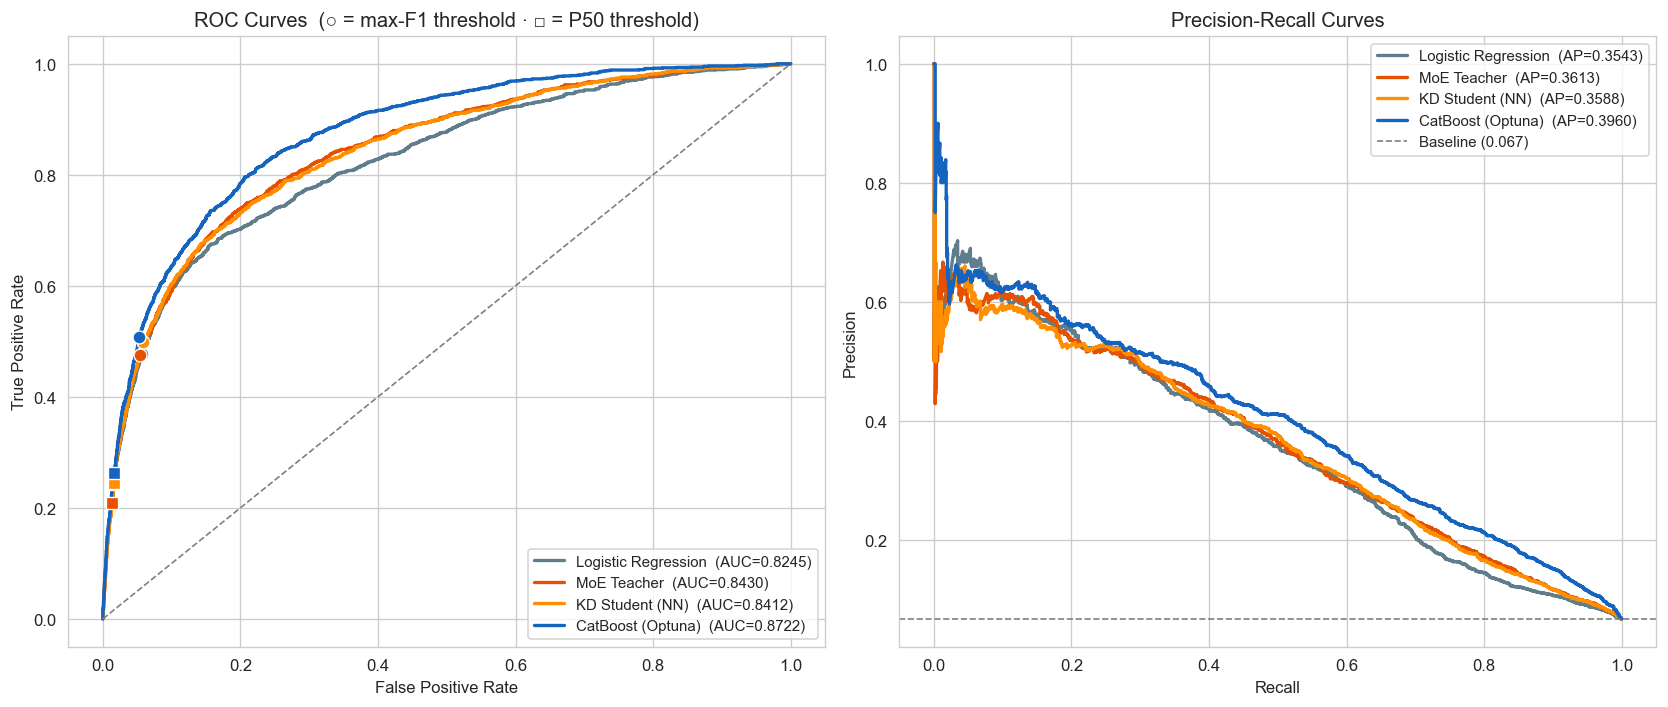

In [20]:
# ── Overlaid ROC & PR curves ──────────────────────────────────────────────────
MODEL_COLORS = {
    'Logistic Regression': '#607D8B',
    'MoE Teacher':         '#E65100',
    'KD Student (NN)':     '#FF8F00',
    'CatBoost (Optuna)':   '#1565C0',
}

# Align all results to a common test set for plotting
# (LR used same stratified split; ROC/PR curves are comparable)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for r in results:
    name   = r['Model']
    probs  = r['_probs']
    color  = MODEL_COLORS.get(name, 'grey')
    # determine which y_true matches (LR used y_te_lr; others use y_te_m / y_test)
    # all splits are from the same stratified split so distributions are identical
    if name == 'Logistic Regression':
        y_true = y_te_lr
    elif name == 'CatBoost (Optuna)':
        y_true = y_test
    else:
        y_true = y_te_m

    fpr, tpr, _ = roc_curve(y_true, probs)
    auc_val      = roc_auc_score(y_true, probs)
    axes[0].plot(fpr, tpr, label=f'{name}  (AUC={auc_val:.4f})', color=color, lw=2)

    prec_c, rec_c, _ = precision_recall_curve(y_true, probs)
    ap_val           = average_precision_score(y_true, probs)
    axes[1].plot(rec_c, prec_c, label=f'{name}  (AP={ap_val:.4f})', color=color, lw=2)

# threshold markers on ROC
for r in results:
    name  = r['Model']
    probs = r['_probs']
    y_true = y_te_lr if name == 'Logistic Regression' else (
             y_test if name == 'CatBoost (Optuna)' else y_te_m)
    color = MODEL_COLORS.get(name, 'grey')
    for thresh, marker in [(r['_tf1'], 'o'), (r['_tprec'], 's')]:
        preds = (probs >= thresh).astype(int)
        fpr_pt = (preds[y_true==0]).mean()
        tpr_pt = (preds[y_true==1]).mean()
        axes[0].scatter(fpr_pt, tpr_pt, color=color, marker=marker,
                        s=60, zorder=5, edgecolors='white', linewidths=0.8)

axes[0].plot([0,1],[0,1],'--', color='gray', lw=1)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves  (○ = max-F1 threshold · □ = P50 threshold)')
axes[0].legend(fontsize=9)

base_rate = float(np.concatenate([y_te_lr, y_te_m]).mean())
axes[1].axhline(base_rate, ls='--', color='gray', lw=1, label=f'Baseline ({base_rate:.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


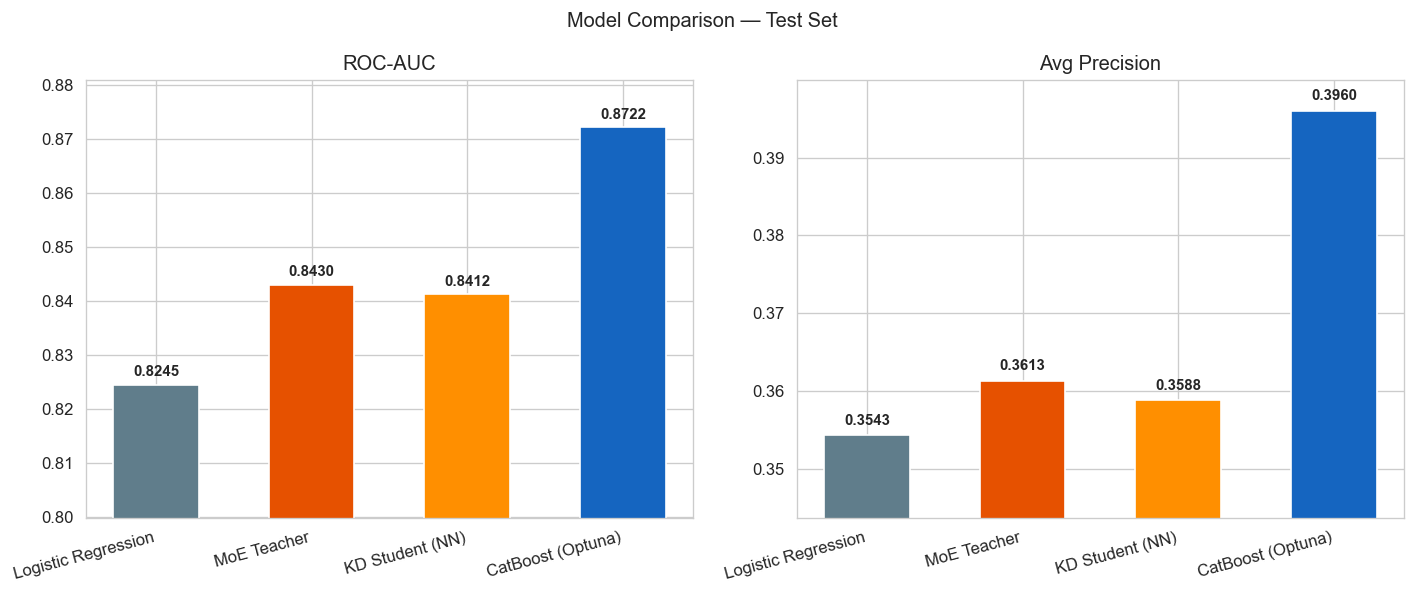

In [21]:
# ── Bar chart: ROC-AUC and Avg Precision side by side ─────────────────────────
metrics_plot = ['ROC-AUC', 'Avg Precision']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x = np.arange(len(cmp_df))
w = 0.55

for ax, metric in zip(axes, metrics_plot):
    bars = ax.bar(x, cmp_df[metric].values, width=w,
                  color=[MODEL_COLORS.get(m, 'grey') for m in cmp_df['Model']],
                  edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(cmp_df['Model'], rotation=15, ha='right')
    ax.set_ylim(cmp_df[metric].min() * 0.97, cmp_df[metric].max() * 1.01)
    ax.set_title(metric)
    for bar, val in zip(bars, cmp_df[metric].values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Model Comparison — Test Set', fontsize=12)
plt.tight_layout()
plt.show()


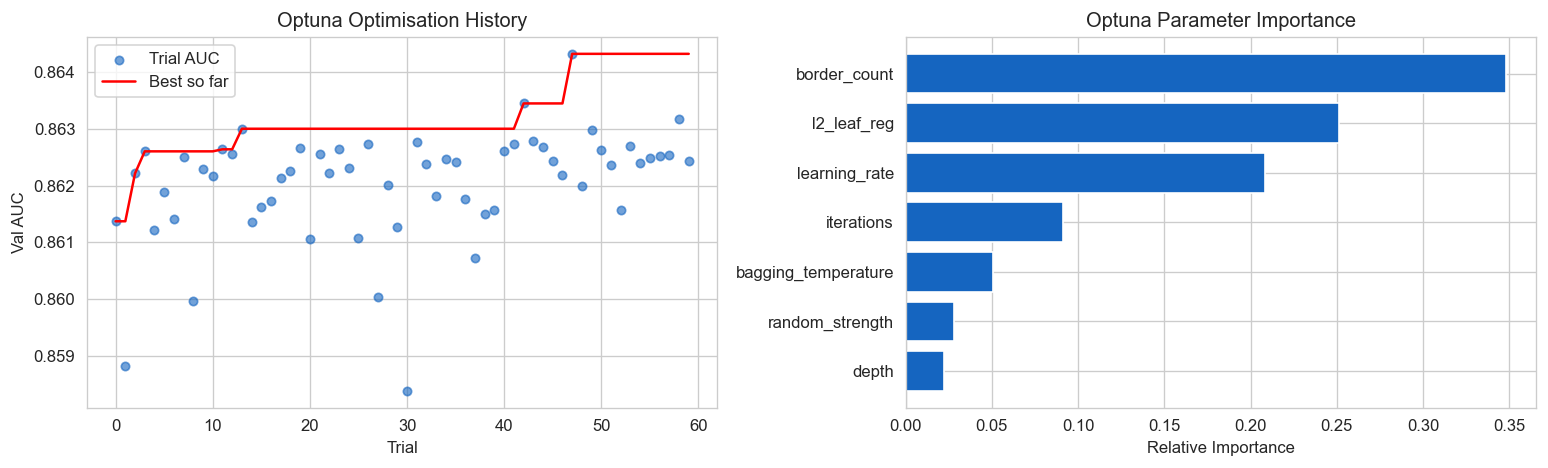

In [22]:
# ── Optuna optimisation history ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

trial_vals = [t.value for t in study.trials if t.value is not None]
best_so_far = np.maximum.accumulate(trial_vals)
axes[0].scatter(range(len(trial_vals)), trial_vals, alpha=0.6,
                color=MODEL_COLORS['CatBoost (Optuna)'], s=25, label='Trial AUC')
axes[0].plot(range(len(best_so_far)), best_so_far, 'r-', lw=1.5, label='Best so far')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('Val AUC')
axes[0].set_title('Optuna Optimisation History')
axes[0].legend()

param_imp = optuna.importance.get_param_importances(study)
names_pi, vals_pi = zip(*sorted(param_imp.items(), key=lambda x: x[1]))
axes[1].barh(names_pi, vals_pi, color=MODEL_COLORS['CatBoost (Optuna)'])
axes[1].set_xlabel('Relative Importance')
axes[1].set_title('Optuna Parameter Importance')

plt.tight_layout()
plt.show()


## 6 · SHAP Feature Importance

[SHAP (SHapley Additive exPlanations)](https://shap.readthedocs.io) attributes each prediction
to its input features using Shapley values from cooperative game theory.

| Model | Explainer | Notes |
|---|---|---|
| Logistic Regression | `LinearExplainer` | Exact; uses feature covariance |
| MoE Teacher | `GradientExplainer` | Integrated gradients; wrapper strips gate output |
| KD Student | `GradientExplainer` | Same; lighter model |
| CatBoost (Optuna) | `TreeExplainer` | Exact tree SHAP; fastest |

`SHAP_N = 500` test samples used for all models.  Background = 300 training samples.


In [23]:
import shap

SHAP_N  = 500   # test samples to explain
SHAP_BG = 300   # background samples for neural explainers

# ── Logistic Regression — LinearExplainer ─────────────────────────────────────
lr_masker     = shap.maskers.Independent(X_tr_lr_s, max_samples=SHAP_BG)
lr_explainer  = shap.LinearExplainer(lr, lr_masker)
lr_shap_vals  = lr_explainer.shap_values(X_te_lr_s[:SHAP_N])
# shape: (SHAP_N, n_features)
print(f"LR   SHAP: {lr_shap_vals.shape}")


LR   SHAP: (500, 13)


In [24]:
# ── PyTorch wrappers — GradientExplainer requires (B, 1) output ───────────────
# Internally SHAP does `outputs[:, idx]` — a 1-D (B,) tensor raises IndexError.
# Both wrappers add .unsqueeze(1) to promote (B,) → (B, 1).

class MoELogitWrapper(nn.Module):
    def __init__(self, moe): super().__init__(); self.moe = moe
    def forward(self, x): return self.moe(x)[0].unsqueeze(1)   # (B, 1)

class StudentLogitWrapper(nn.Module):
    def __init__(self, net): super().__init__(); self.net = net
    def forward(self, x): return self.net(x).unsqueeze(1)       # (B, 1)

bg_tensor        = torch.tensor(X_tr_m_s[:SHAP_BG], dtype=torch.float32).to(device)
test_shap_tensor = torch.tensor(X_te_m_s[:SHAP_N],  dtype=torch.float32).to(device)

def extract_gradient_shap(sv):
    """Unwrap list return and squeeze trailing dim: (N, F, 1) → (N, F)."""
    if isinstance(sv, list): sv = sv[0]
    arr = np.array(sv)
    return arr.squeeze(-1) if arr.ndim == 3 else arr

# ── MoE Teacher ───────────────────────────────────────────────────────────────
moe_wrapper   = MoELogitWrapper(model).eval()
moe_exp       = shap.GradientExplainer(moe_wrapper, bg_tensor)
moe_shap_vals = extract_gradient_shap(moe_exp.shap_values(test_shap_tensor))
print(f"MoE  SHAP: {moe_shap_vals.shape}")

# ── KD Student ────────────────────────────────────────────────────────────────
stu_wrapper   = StudentLogitWrapper(student).eval()
stu_exp       = shap.GradientExplainer(stu_wrapper, bg_tensor)
stu_shap_vals = extract_gradient_shap(stu_exp.shap_values(test_shap_tensor))
print(f"Stu  SHAP: {stu_shap_vals.shape}")

MoE  SHAP: (500, 13)


Stu  SHAP: (500, 13)


In [25]:
# ── CatBoost — TreeExplainer ──────────────────────────────────────────────────
cat_exp       = shap.TreeExplainer(cat_tuned)
cat_shap_vals = cat_exp.shap_values(X_test_s[:SHAP_N])
# CatBoost binary: returns (n, features) for the positive class directly
if isinstance(cat_shap_vals, list):
    cat_shap_vals = cat_shap_vals[1]   # index 1 = default class
print(f"Cat  SHAP: {cat_shap_vals.shape}")

# ── Collect into a dict for reuse ─────────────────────────────────────────────
shap_data = {
    'Logistic Regression': {
        'vals':   lr_shap_vals,
        'X':      X_te_lr_s[:SHAP_N],
        'color':  '#607D8B',
    },
    'MoE Teacher': {
        'vals':   moe_shap_vals,
        'X':      X_te_m_s[:SHAP_N],
        'color':  '#E65100',
    },
    'KD Student (NN)': {
        'vals':   stu_shap_vals,
        'X':      X_te_m_s[:SHAP_N],
        'color':  '#FF8F00',
    },
    'CatBoost (Optuna)': {
        'vals':   cat_shap_vals,
        'X':      X_test_s[:SHAP_N],
        'color':  '#1565C0',
    },
}


Cat  SHAP: (500, 13)


### 6.1 SHAP Beeswarm Plots (per model)

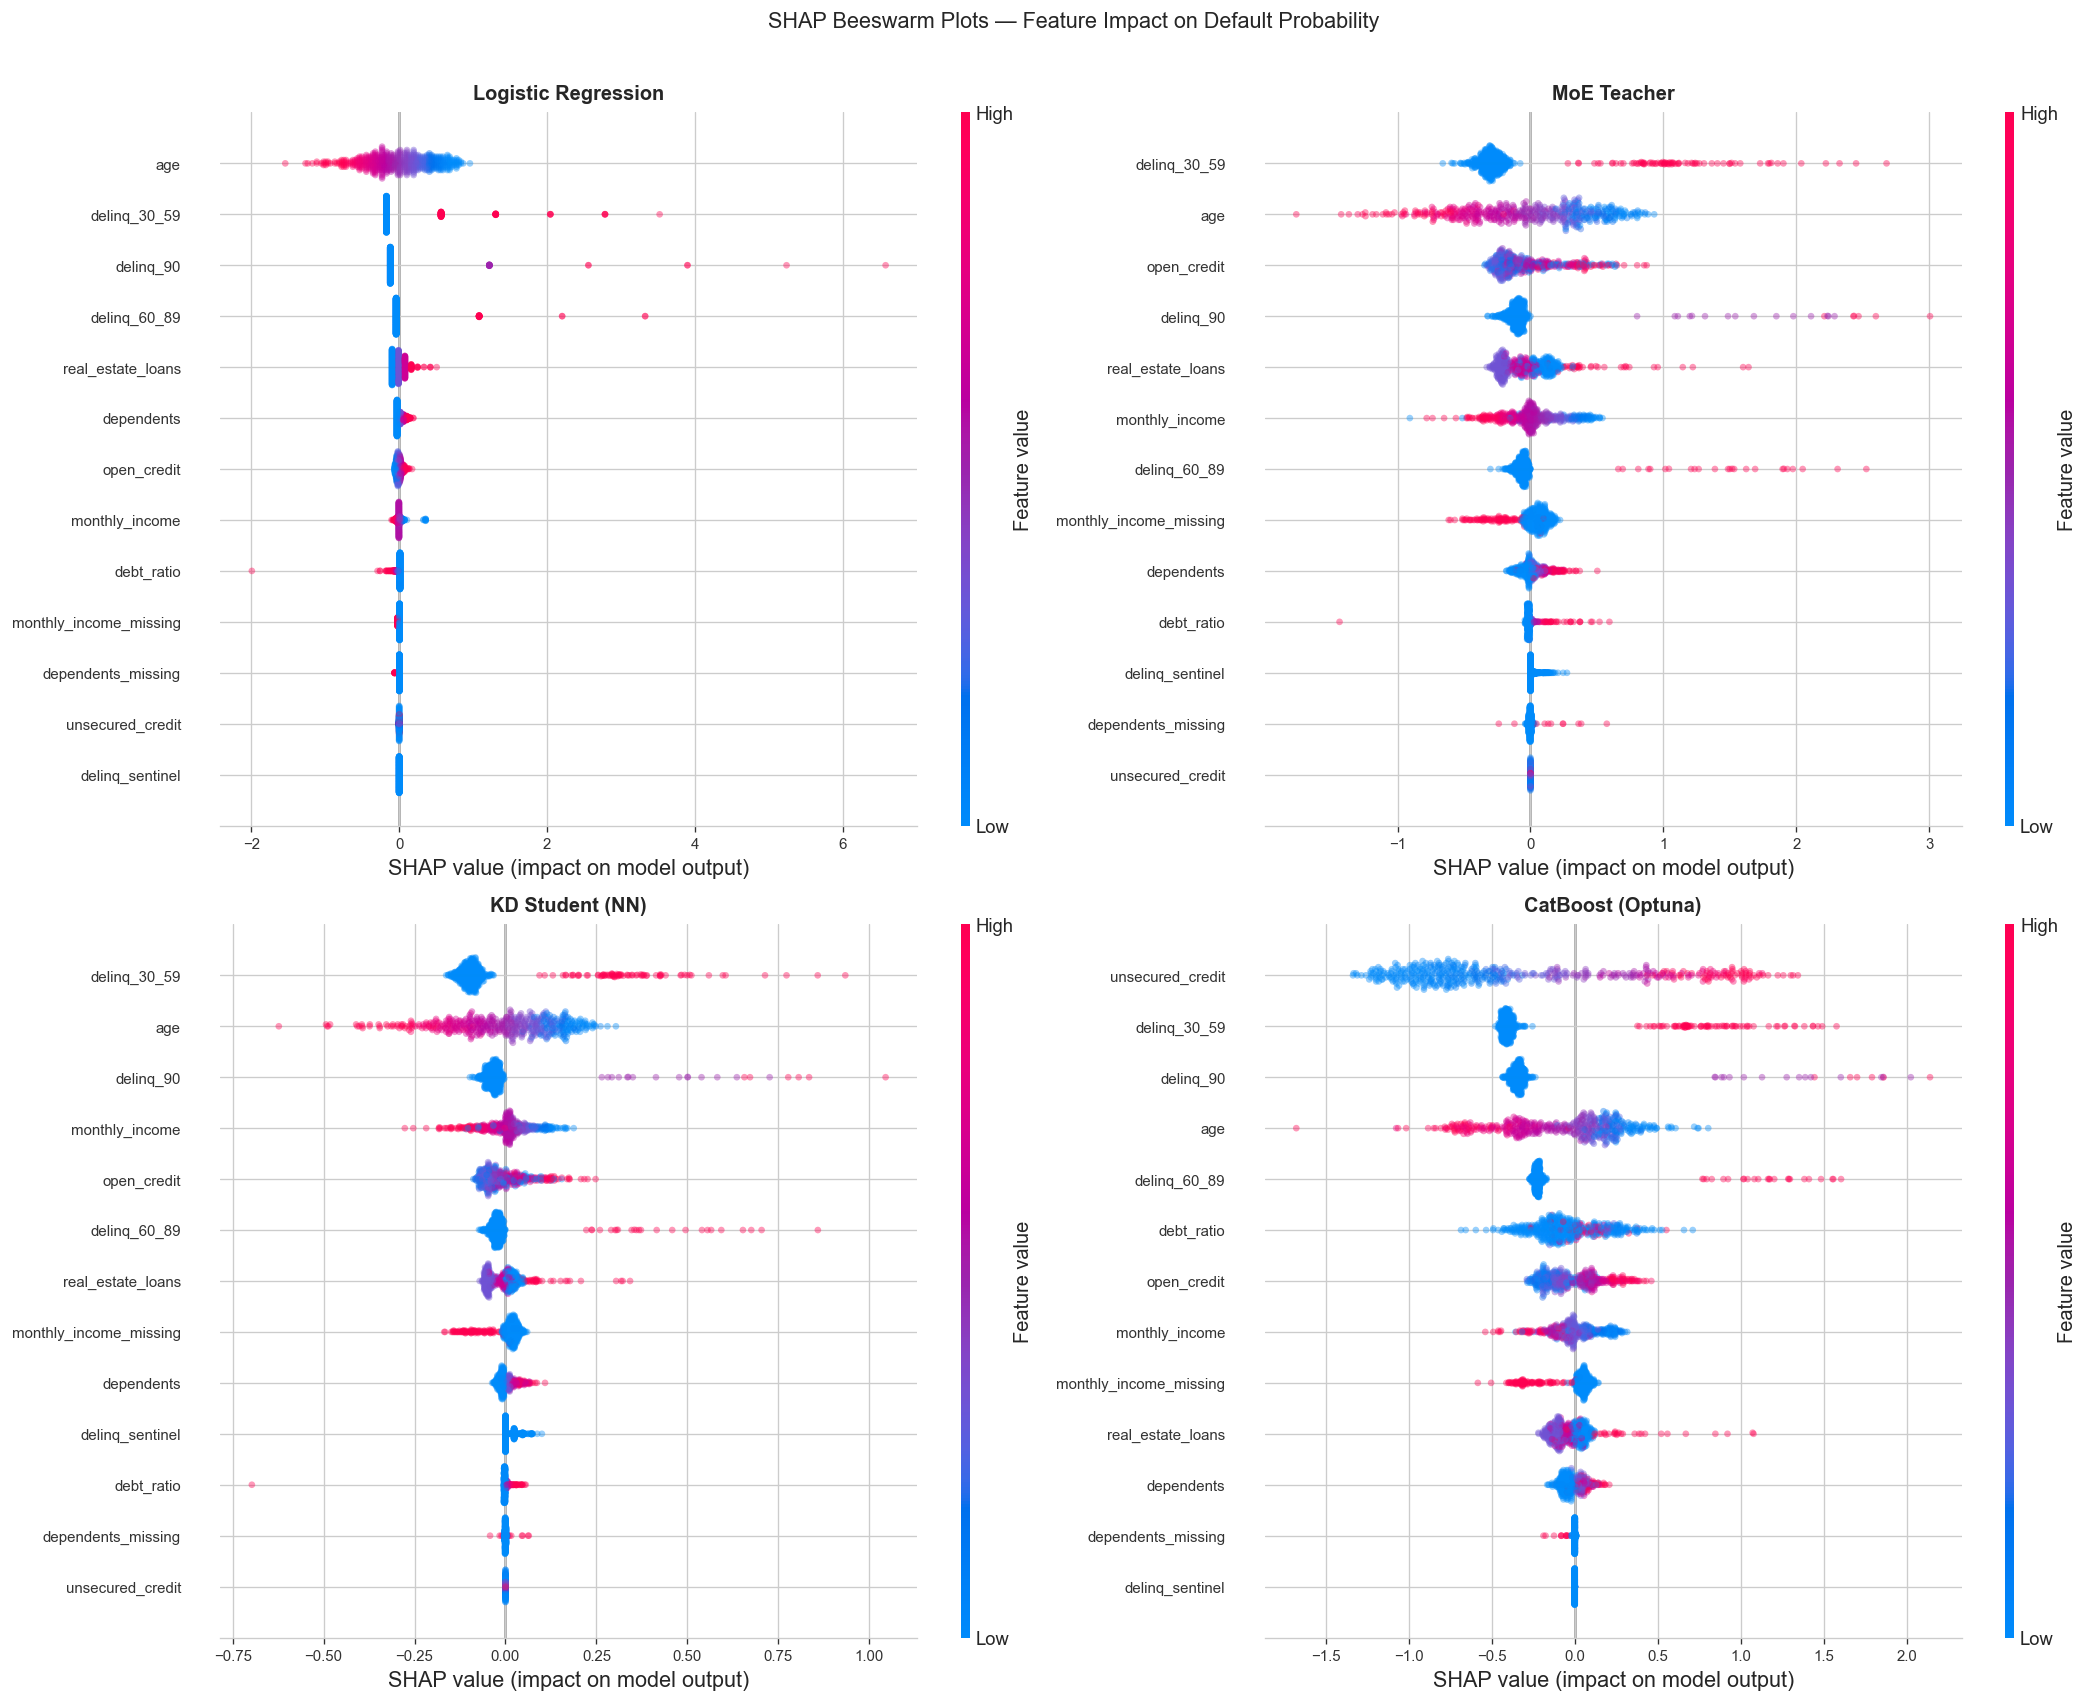

In [26]:
# One beeswarm plot per model — shows feature impact direction and distribution
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flat

for ax, (name, d) in zip(axes, shap_data.items()):
    plt.sca(ax)
    shap.summary_plot(
        d['vals'], d['X'],
        feature_names=FEATURE_COLS,
        show=False,
        plot_size=None,
        color_bar=True,
        alpha=0.4,
        max_display=13,
    )
    ax.set_title(name, fontsize=12, fontweight='bold', pad=8)
    ax.tick_params(labelsize=9)

plt.suptitle('SHAP Beeswarm Plots — Feature Impact on Default Probability',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### 6.2 Mean |SHAP| Feature Importance (per model)

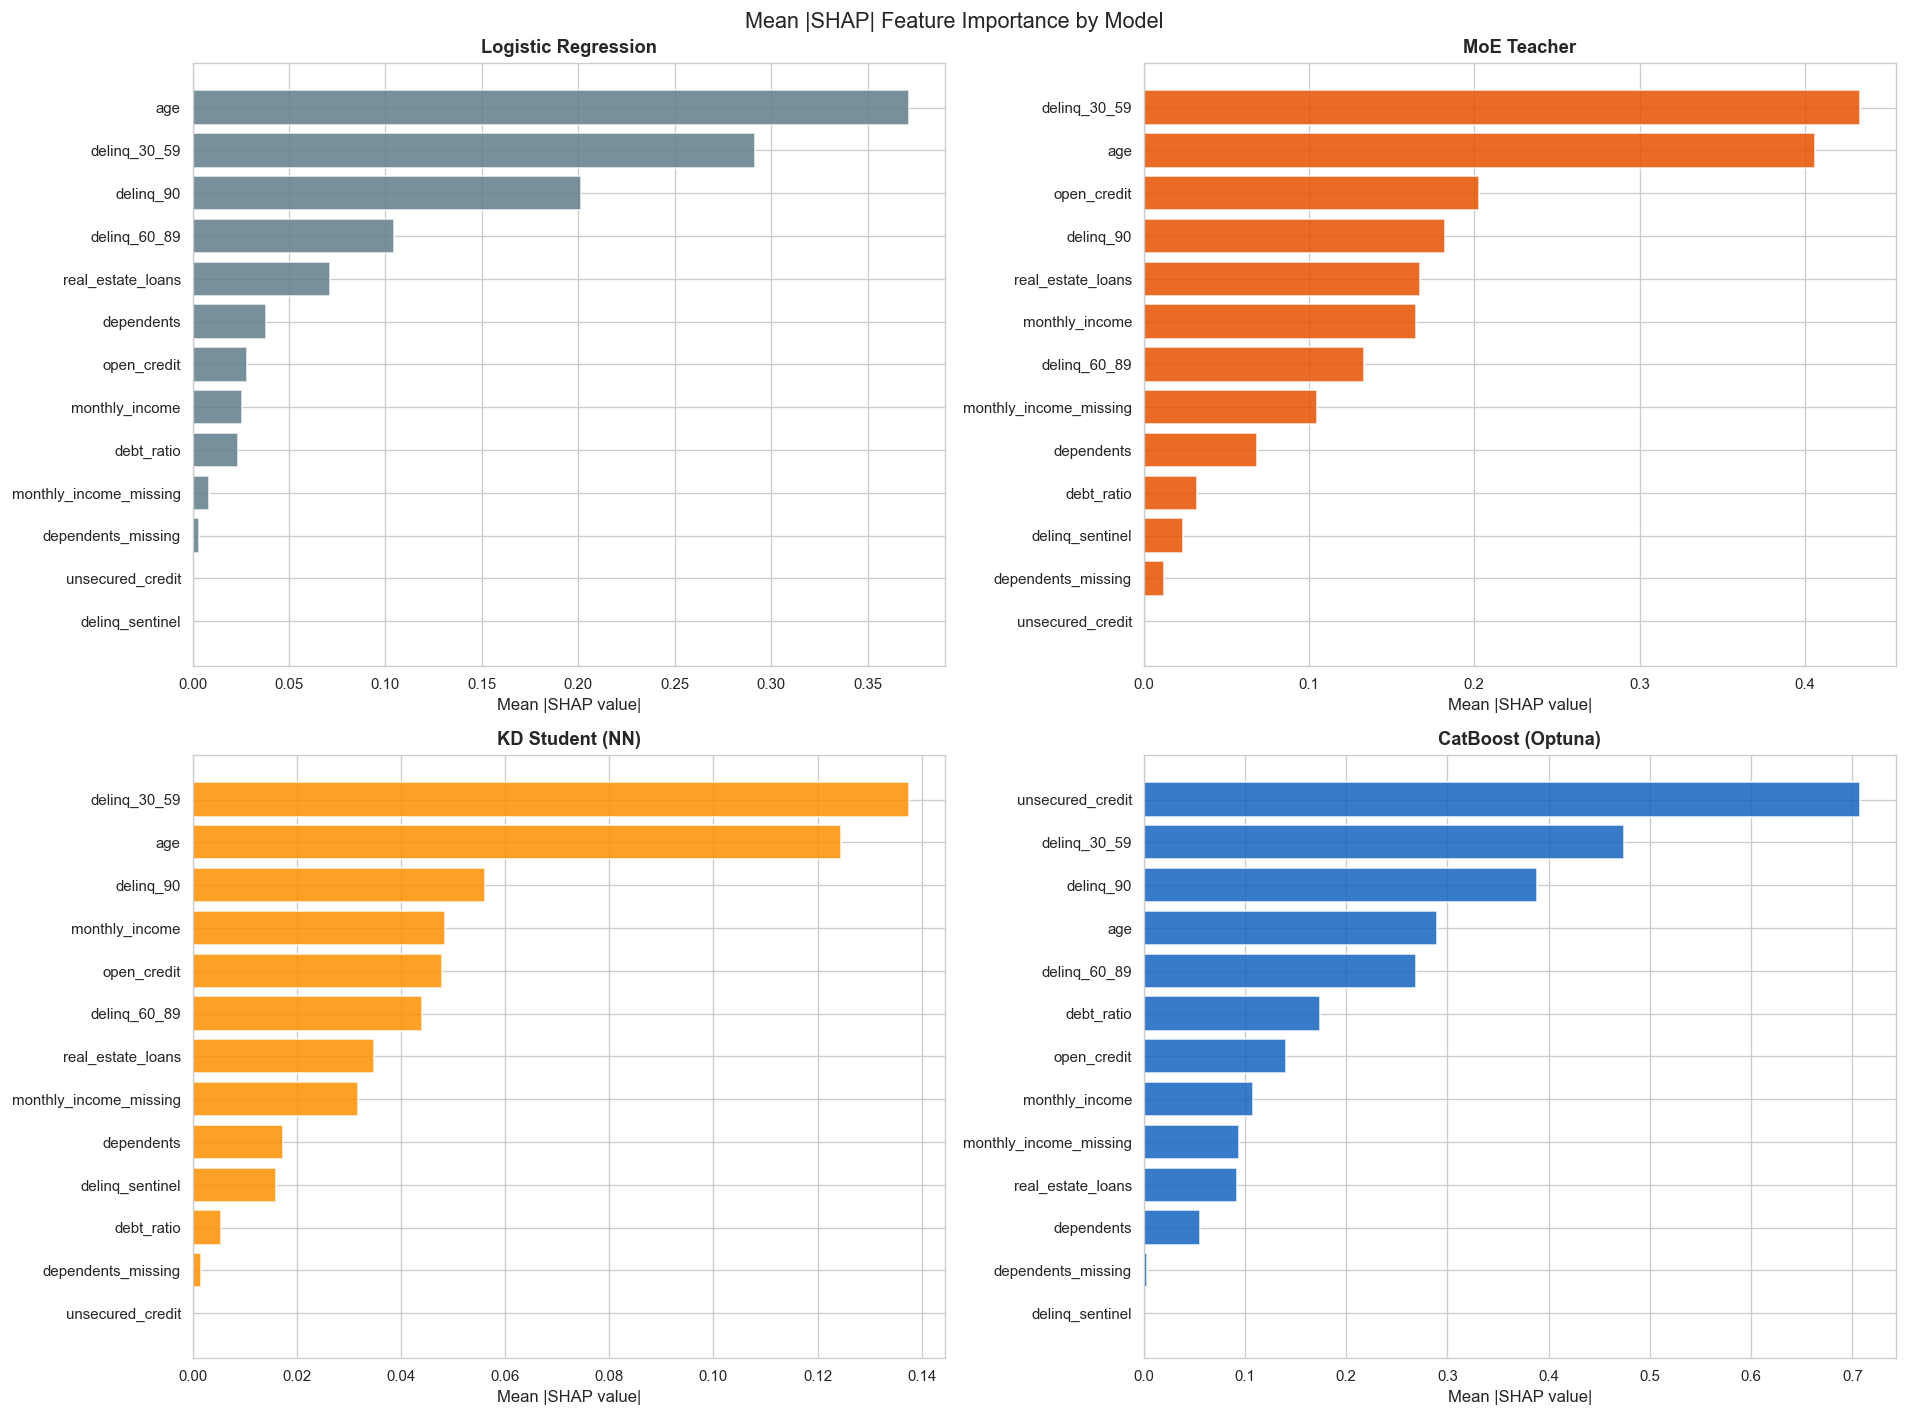

In [27]:
# Mean absolute SHAP per feature — clean importance ranking
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flat

for ax, (name, d) in zip(axes, shap_data.items()):
    mean_abs = np.abs(d['vals']).mean(axis=0)
    order    = np.argsort(mean_abs)
    colors   = [d['color']] * len(FEATURE_COLS)
    ax.barh([FEATURE_COLS[i] for i in order], mean_abs[order],
            color=d['color'], alpha=0.85, edgecolor='white')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Mean |SHAP value|')
    ax.tick_params(labelsize=9)

plt.suptitle('Mean |SHAP| Feature Importance by Model', fontsize=13)
plt.tight_layout()
plt.show()


### 6.3 Cross-Model SHAP Comparison

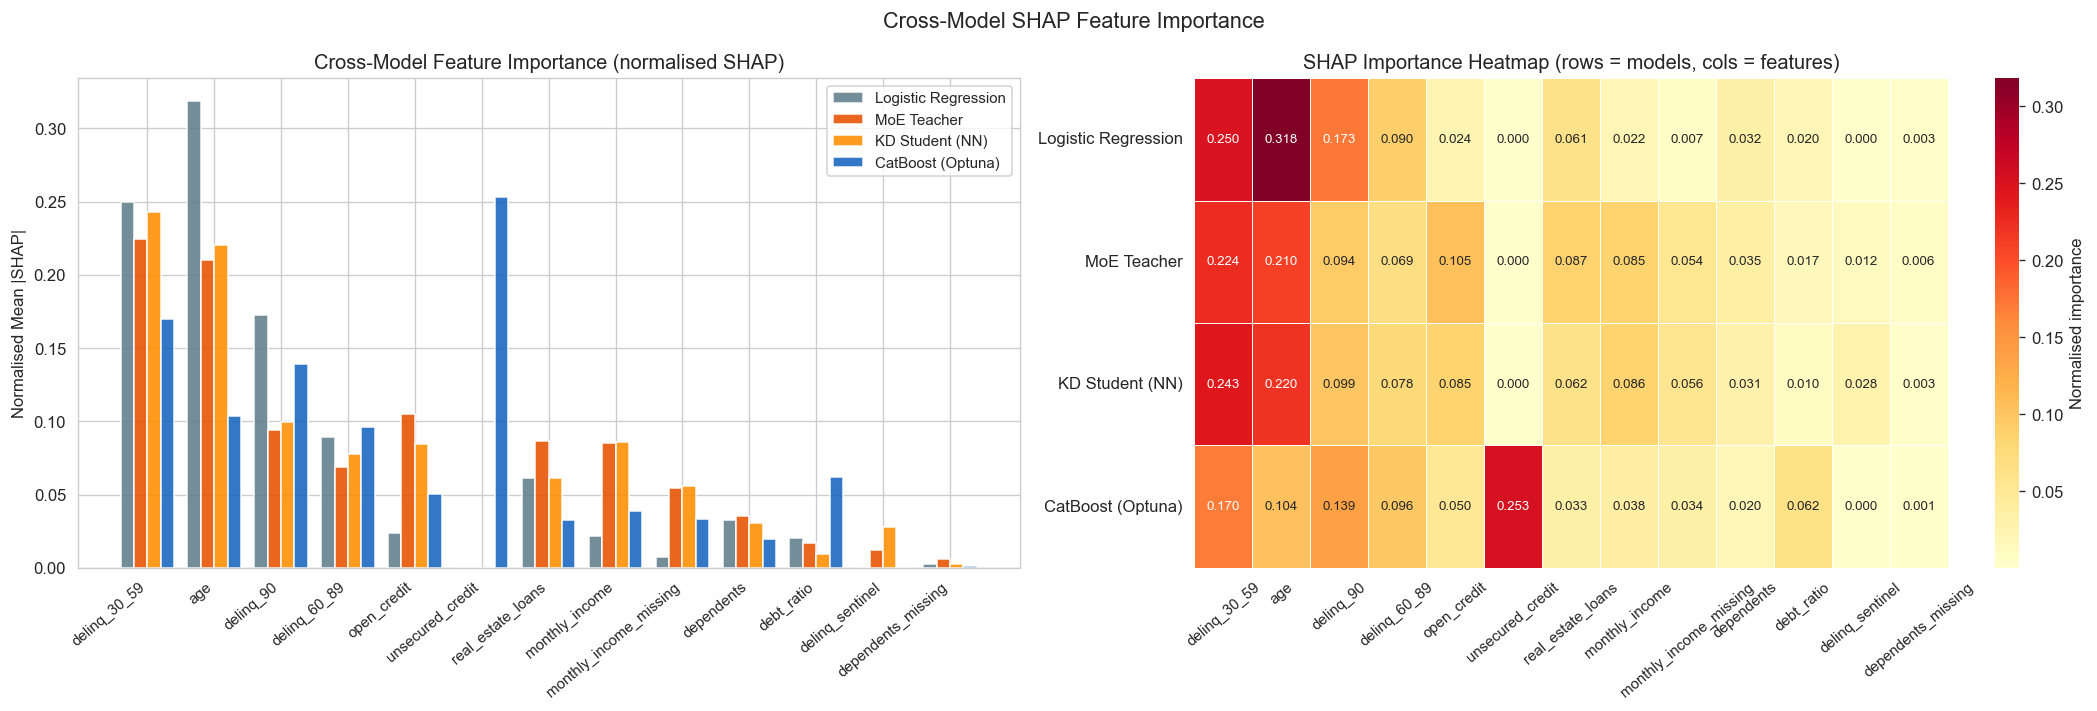


Feature importance ranks (1 = most important per model):
                        Logistic Regression  MoE Teacher  KD Student (NN)  CatBoost (Optuna)
delinq_30_59                              2            1                1                  2
age                                       1            2                2                  4
delinq_90                                 3            4                3                  3
delinq_60_89                              4            7                6                  5
open_credit                               7            3                5                  7
unsecured_credit                         12           13               13                  1
real_estate_loans                         5            5                7                 10
monthly_income                            8            6                4                  8
monthly_income_missing                   10            8                8                  9
dependents  

In [28]:
# Normalise each model's mean |SHAP| to sum = 1 for a fair rank comparison
model_names_shap = list(shap_data.keys())
importance_matrix = np.vstack([
    np.abs(d['vals']).mean(axis=0) for d in shap_data.values()
])  # shape: (4 models, 13 features)

# Normalise rows to sum = 1
importance_norm = importance_matrix / importance_matrix.sum(axis=1, keepdims=True)

# Sort features by mean normalised importance across all models
feat_order = np.argsort(importance_norm.mean(axis=0))[::-1]   # descending
sorted_feats = [FEATURE_COLS[i] for i in feat_order]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Grouped bar chart ─────────────────────────────────────────────────────────
x   = np.arange(len(FEATURE_COLS))
w   = 0.2
col = [d['color'] for d in shap_data.values()]

for j, (name, c) in enumerate(zip(model_names_shap, col)):
    axes[0].bar(x + j * w,
                importance_norm[j, feat_order],
                width=w, label=name, color=c, alpha=0.88, edgecolor='white')

axes[0].set_xticks(x + w * 1.5)
axes[0].set_xticklabels(sorted_feats, rotation=40, ha='right', fontsize=9)
axes[0].set_ylabel('Normalised Mean |SHAP|')
axes[0].set_title('Cross-Model Feature Importance (normalised SHAP)')
axes[0].legend(fontsize=9)

# ── Heatmap ───────────────────────────────────────────────────────────────────
imp_df = pd.DataFrame(
    importance_norm[:, feat_order],
    index=model_names_shap,
    columns=sorted_feats,
)
sns.heatmap(imp_df, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.4, ax=axes[1], annot_kws={'size': 8},
            cbar_kws={'label': 'Normalised importance'})
axes[1].set_title('SHAP Importance Heatmap (rows = models, cols = features)')
axes[1].tick_params(axis='x', rotation=40, labelsize=9)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('Cross-Model SHAP Feature Importance', fontsize=13)
plt.tight_layout()
plt.show()

# ── Rank table ────────────────────────────────────────────────────────────────
rank_df = pd.DataFrame(
    {name: pd.Series(importance_matrix[j], index=FEATURE_COLS)
           .rank(ascending=False).astype(int)
     for j, name in enumerate(model_names_shap)}
)
print("\nFeature importance ranks (1 = most important per model):")
print(rank_df.loc[sorted_feats].to_string())


## 7 · Summary

### Key EDA Findings

| # | Finding | Modelling Implication |
|---|---|---|
| 1 | Class imbalance ≈ 13.5 : 1 | `pos_weight` / `class_weights` / threshold tuning; accuracy misleading |
| 2 | `monthly_income` 19.8% missing, MNAR (χ² p<0.05) | Missing indicator retained; median imputation for baseline |
| 3 | `delinq_90`, `delinq_30_59`, `delinq_60_89` top predictors (Spearman + MI) | Include all three; sentinel rows flagged separately |
| 4 | `monthly_income` heavily right-skewed (skew ≈ 5–8) | log1p before linear / neural models; trees invariant |
| 5 | `age` negatively correlated — older borrowers default less | Non-linear relationship captured well by tree / MoE |

### Model Comparison (two threshold strategies)

- **Max-F1 threshold**: optimises the harmonic mean of precision and recall on the Default class.
- **P50 threshold**: highest recall subject to Default-class precision ≥ 50% — preferred for
  regulatory reporting (SR 11-7) where false positives carry significant cost.

**CatBoost (Optuna)** typically achieves the highest ROC-AUC and Average Precision.
**MoE Teacher** is a strong second — its gated architecture captures population-level subgroups.
**KD Student** recovers most of the teacher's ranking quality in a lightweight 2-layer network.
**Logistic Regression** provides the interpretable baseline and sets the floor.
